In [1]:
import numpy as np
import pandas as pd
import matplotlib .pyplot as plt
import cv2

#### 0) Lectura de datos

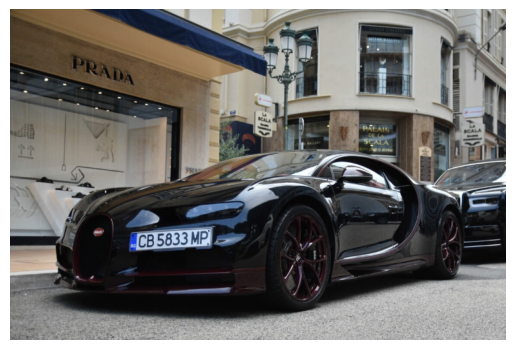

In [2]:
# Cargar la imagen 'auto_1.jpg' con opencv
img = cv2.imread('auto_1.jpg')

# Convertir la imagen a formato RGB
img_rgb = cv2.cvtColor(img , cv2. COLOR_BGR2RGB)

# Redimensionar la imagen mediante el método de opencv "resize()" a un tamaño de (768,512)
img_rgb_resized = cv2.resize(img_rgb, (768,512))

# Visualizar la imagen
plt.imshow(img_rgb_resized)
plt.axis("off")
plt.show()

#### 1) Detección de bordes con Canny

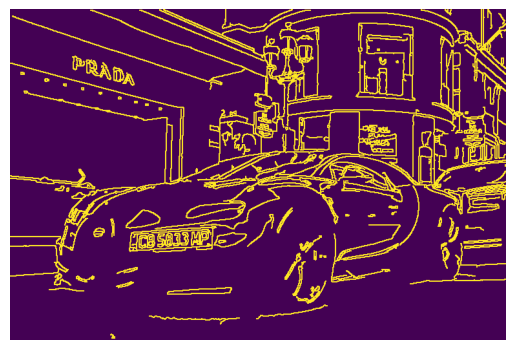

In [12]:
# Aplicar un filtro gaussiano con un kernel de 3x3
img_gaus = cv2.GaussianBlur(img_rgb_resized , (3,3), 0)

# Aplicar el método de Canny para la detección de bordes
canny = cv2.Canny(img_gaus , 255/3, 255) # minValue and maxValue. Canny recomienda que minValue sea 3 veces mayor que maxValue

# Aplicar una dilatación con un kernel de 2x2 y 1 iteración
kernel = np.ones((2,2), 'uint8')
canny = cv2.dilate(canny, kernel, iterations=1)

# Visualizar la máscara resultante
plt.imshow(canny)
plt.axis("off")
plt.show()

#### 2) Procesamiento mediante operaciones morfológicas

C:\Users\Acer Predator\AppData\Local\Temp\ipykernel_18380\911890350.py:3: DeprecationWarning: Please import `binary_fill_holes` from the `scipy.ndimage` namespace; the `scipy.ndimage.morphology` namespace is deprecated and will be removed in SciPy 2.0.0.
  from scipy.ndimage.morphology import binary_fill_holes as bfh


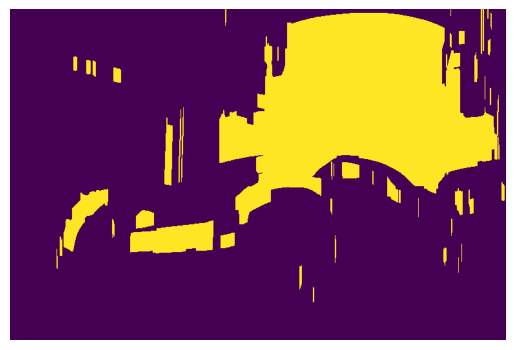

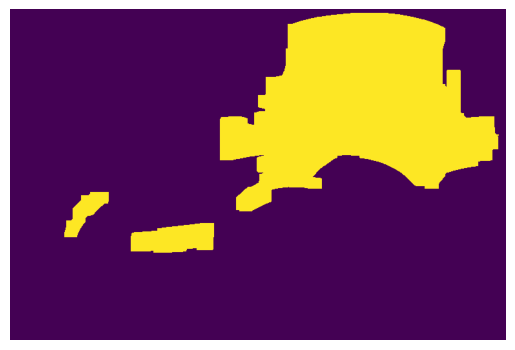

In [39]:
# Aplicar el comando "binary_fill_holes" sobre los bordes detectados.
# Nota: convertir la imagen a formato "uint8"
from scipy.ndimage.morphology import binary_fill_holes as bfh
from skimage.morphology import remove_small_objects
bordes = canny.copy()
bordes = bfh(bordes)
bordes = (bordes.astype(np.uint8))*255 # Convertir a uint8 (0 y 255)

# Aplicar una apertura en el eje vertical con un kernel de 20x1 y 1 iteración para eliminar bordes verticales. 
# Nota: Aplicar el método de opencv "mophologyEx()" con cv2.MORPH_OPEN. 

# Crear kernel vertical 20x1
kernel_vertical = cv2.getStructuringElement(cv2.MORPH_RECT, (1, 20))

# Aplicar apertura morfológica
apertura_vertical = cv2.morphologyEx(bordes, cv2.MORPH_OPEN, kernel_vertical, iterations=1)

# Mostrar resultado
plt.imshow(apertura_vertical)
plt.axis("off")
plt.show()

# Aplicar una apertura en el eje horizontal con un kernel de 1x20 y 1 iteración para eliminar bordes horizontales
kernel_horizontal = cv2.getStructuringElement(cv2.MORPH_RECT, (20, 1))

apertura_horizontal = cv2.morphologyEx(apertura_vertical, cv2.MORPH_OPEN, kernel_horizontal, iterations=1)

# Eliminar artefactos, es decir, objetos cuya área tenga menos de 1000 píxeles con una connectivity=8.  
# Nota: utilizar el método "remove_small_objects()" sobre la máscara anterior en formato booleano. 
mascara = apertura_horizontal > 0

mascara = remove_small_objects(mascara, min_size=1000, connectivity=8)   # 8-conectividad en 2D

# Convertir la máscara resultante a formato uint8
mascara = (mascara.astype(np.uint8))*255

# Visualizar la máscara resultante
plt.imshow(mascara)
plt.axis("off")
plt.show()

#### 3) Detección automática de la región de interés correspondiente a la matrícula

[[1.         0.68988866]
 [2.         0.33188444]
 [3.         0.29992702]]


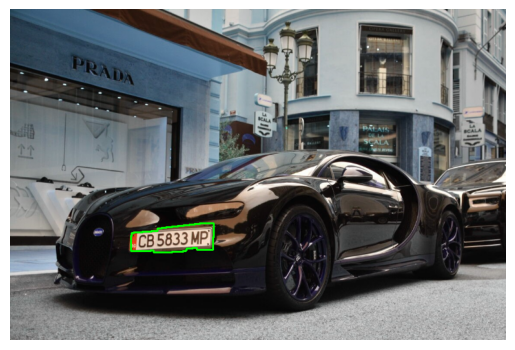

In [40]:
from skimage.measure import label, regionprops

# Crear una imagen de etiquetas mediante el comando "label"
lab, num = label(mascara, return_num=True)
props = regionprops(lab)

# Calcular la proporción (cociente) entre el minor_axis_length y el major_axis_length para cada objeto de la imagen de etiquetas
ratios = []
for r in props:
    ratios.append((r.label, r.minor_axis_length / r.major_axis_length))

ratios = np.array(ratios)
print(ratios)

# Generar una máscara que contenga únicamente el objeto de la menor proporción. 
label_min_ratio, min_ratio = min(ratios, key=lambda x: x[1])

mascara_min_ratio = (lab == label_min_ratio)

# Dibujar los contornos de la máscara sobre la imagen original y visualizar el resultado
mascara_min_ratio = mascara_min_ratio.astype(np.uint8)*255

contorno, hierarchy = cv2.findContours(mascara_min_ratio, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

img_contorno = img_rgb_resized.copy() # si viene de cv2.imread, esto está en BGR

cv2.drawContours(img_contorno, contorno, contourIdx=-1, color=(0, 255, 0), thickness=2) # verde en BGR 


plt.imshow(cv2.cvtColor(img_contorno, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()

#### 4) Procesamiento de la región de interés

Bounding box (x, y, w, h): 187 331 129 46
Orientation (radianes): -1.4751362277241697
Ángulo de rotación (grados): -5.480919944555978


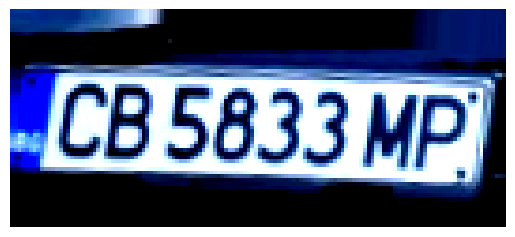

In [ ]:
import math
# Calcular la boundingbox de la máscara
contorno_max = max(contorno, key=cv2.contourArea) # Nos quedamos con el contorno de mayor área
x, y, w, h = cv2.boundingRect(contorno_max)
print("Bounding box (x, y, w, h):", x, y, w, h)

# Hacer un crop de la imagen original a partir de las coordenadas de la boundingbox
crop = img_rgb_resized[y:y+h, x:x+w].copy()

# Calcular la orientación de la máscara. 
mask_bool = (mascara_min_ratio > 0)
props_mask = regionprops(mask_bool.astype(np.uint8))

orientation = props_mask[0].orientation  # en radianes
print("Orientation (radianes):", orientation)


# Hacer una conversión mediante la siguiente fórmula:
    # angle = (orientation*90)/(math.pi/2). Nota: utilizar "import math"
    # Si 'angle' es mayor que 0, la orientación será igual a 90-angle
    # Si no, la orientación será igual a -(90+angle)
angle = (orientation*90)/(math.pi/2)

if angle > 0:
    ang_rot = 90 - angle
else:
    ang_rot = -(90 + angle)

print("Ángulo de rotación (grados):", ang_rot)

# Aplicar una transformación geométrica de rotación para orientar horizontalmente el crop de la imagen obtenido anteriormente
(hc, wc) = crop.shape[:2]
center = (wc / 2, hc / 2)

M = cv2.getRotationMatrix2D(center, ang_rot, 1.0)

cos = abs(M[0, 0])
sin = abs(M[0, 1])
new_w = int((hc * sin) + (wc * cos))
new_h = int((hc * cos) + (wc * sin))

M[0, 2] += (new_w / 2) - center[0]
M[1, 2] += (new_h / 2) - center[1]

crop_rot = cv2.warpAffine(crop, M, (new_w, new_h), flags=cv2.INTER_LINEAR, borderMode=cv2.BORDER_REPLICATE)

# Aumentar el contraste 100 unidades de acuerdo a la fórmula vista en clase. 
C = 100
factor = (259*(C+255))/(255*(259-C))

contraste = factor * (crop_rot.astype(np.float32) - 128) + 128
contraste = np.clip(contraste, 0, 255).astype(np.uint8)

# Visualizar el resultado la matrícula con el contraste aumentado
plt.imshow(contraste, cmap="gray")
plt.axis("off")
plt.show()

#### 5) Convertir el contenido de la imagen en un string mediante la librería 'pytesseract'
Para instalar la librería pytesseract:
    
    Descargar el ejecutable en -->  https://github.com/UB-Mannheim/tesseract/wiki
    Instalar la librería haciendo --> pip install pytesseract

Si se tienen dudas, consultar el siguiente vídeo:

    https://www.youtube.com/watch?v=_j6o2rBkhhg

Texto OCR bruto: WCB 5833 MP)

Texto OCR limpio: WCB5833MP


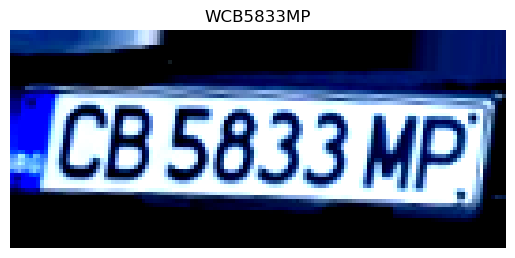

In [42]:
# Crear la ruta de pytesseract que contenga el ejecutable
import pytesseract
pytesseract.pytesseract.tesseract_cmd = r"C:\Program Files\Tesseract-OCR\tesseract.exe"
# Convertir el contenido de la imagen en una variable de tipo string.
# Importante: utiliza la opción --> config='--psm 10'
string = pytesseract.image_to_string(contraste, config='--psm 10')

print("Texto OCR bruto:", string)

# Eliminar del string los caracteres especiales mediante la siguiente línea de código:
string = ''.join(filter(str.isalnum, string))
print("Texto OCR limpio:", string)

# Visualizar la imagen original y ponle el título extraído automáticamente mediante la librería "pytesseract"
plt.imshow(contraste)
plt.title(string)
plt.axis("off")
plt.show()
